<a href="https://colab.research.google.com/github/laibatabassum456/Data_Analysis/blob/main/Loan_Acceptance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATA

In [7]:
df = pd.read_csv('/content/bank-full.csv', sep=';')

UNDERSTAND DATA

In [19]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45210 entries, 0 to 45209
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45210 non-null  int64
 1   balance              45210 non-null  int64
 2   day                  45210 non-null  int64
 3   durations            45210 non-null  int64
 4   campaign             45210 non-null  int64
 5   pdays                45210 non-null  int64
 6   previous             45210 non-null  int64
 7   y                    45210 non-null  int64
 8   job_blue-collar      45210 non-null  bool 
 9   job_entrepreneur     45210 non-null  bool 
 10  job_housemaid        45210 non-null  bool 
 11  job_management       45210 non-null  bool 
 12  job_retired          45210 non-null  bool 
 13  job_self-employed    45210 non-null  bool 
 14  job_services         45210 non-null  bool 
 15  job_student          45210 non-null  bool 
 16  job_technician       4

,age,balance,day,durations,campaign,pdays,previous,y
count,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000
mean,40.936297,1362.236474,15.806392,258.160805,2.763858,40.194559,0.580093,0.116987
std,10.618863,3044.790103,8.322566,257.530206,3.098053,100.127440,2.302945,0.321409
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1427.750000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


HANDLE MISSING VALUES

In [20]:
df.isnull().sum()
df.ffill(inplace=True)

/tmp/ipykernel_3864/2903114193.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


VISUALIZATION

Age Distribution

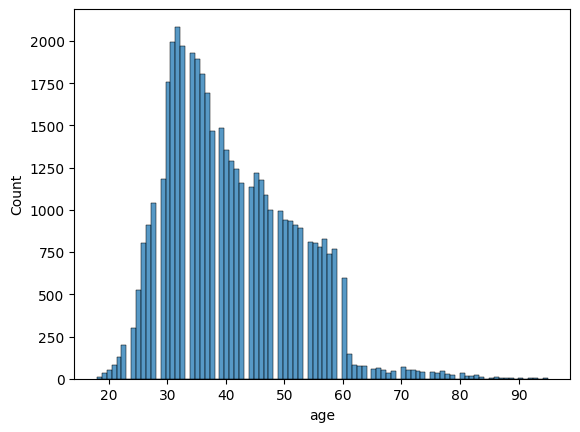

In [21]:
sns.histplot(df['age'])
plt.show()

Job vs Loan Acceptance

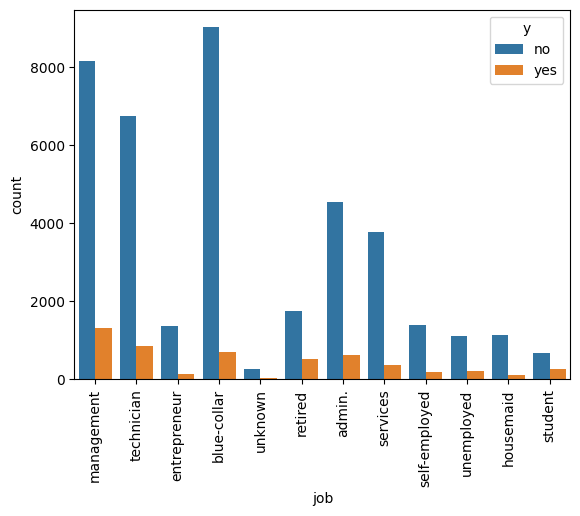

In [9]:
 sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=90)
plt.show()

Marital Status

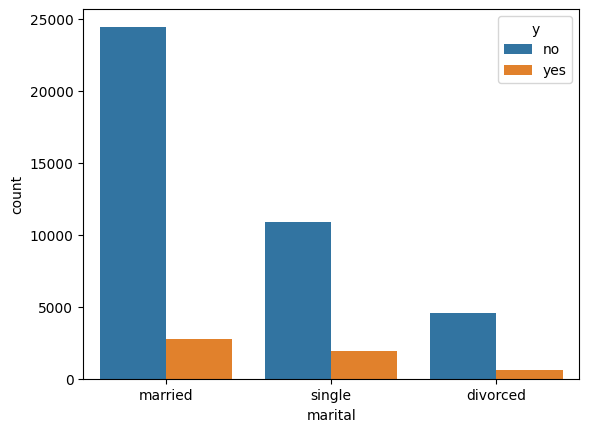

In [10]:
sns.countplot(x='marital', hue='y', data=df)
plt.show()

CONVERT TARGET COLUMN

In [11]:
 df['y'] = df['y'].map({'yes':1, 'no':0})

ENCODE CATEGORICAL DATA

In [12]:
df = pd.get_dummies(df, drop_first=True)

DEFINE INPUT & OUTPUT

In [13]:
 X = df.drop('y', axis=1)
y = df['y']

 TRAIN-TEST SPLIT

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

TRAIN MODEL

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=300)

PREDICTION

In [16]:
 y_pred = model.predict(X_test)

 EVALUATION

In [17]:
 from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8979208139792081
[[7815  185]
 [ 738  304]]


BUSINESS INSIGHTS

In [22]:
# Identify columns that originated from 'job' after one-hot encoding
job_dummy_cols = [col for col in df.columns if col.startswith('job_')]

print("Mean 'y' (loan acceptance) for each job category:")
# Calculate mean 'y' for each existing job dummy variable
for col in job_dummy_cols:
    job_category_name = col.replace('job_', '')
    mean_acceptance = df[df[col] == 1]['y'].mean()
    print(f"  {job_category_name}: {mean_acceptance:.4f}")

# Note: Due to 'drop_first=True' in pd.get_dummies, one original job category
# is not represented by a separate dummy column (e.g., 'admin.' if it was the first alphabetically).
# Its influence is implicitly captured when all other 'job_' dummy columns are 0.

Mean 'y' (loan acceptance) for each job category:
  blue-collar: 0.0727
  entrepreneur: 0.0828
  housemaid: 0.0879
  management: 0.1376
  retired: 0.2279
  self-employed: 0.1184
  services: 0.0888
  student: 0.2868
  technician: 0.1106
  unemployed: 0.1550
  unknown: 0.1181


This project predicts customer response to a personal loan offer.
After analyzing the dataset, Logistic Regression was used to build the model.
The results show that factors like job type, age, and marital status influence loan acceptance.